In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)

print(
    "GPU Available:",
    len(tf.config.list_physical_devices('GPU')) > 0
)

TensorFlow version: 2.21.0
GPU Available: False


In [2]:
train = pd.read_csv(r"D:\Projects\Exoplanet-Detection\data\processed\train.csv")
val = pd.read_csv(r"D:\Projects\Exoplanet-Detection\data\processed\val.csv")
test = pd.read_csv(r"D:\Projects\Exoplanet-Detection\data\processed\test.csv")

X_train = train.drop('label', axis=1).values
y_train = train['label'].values
X_val = val.drop('label', axis=1).values
y_val = val['label'].values
X_test = test.drop('label', axis=1).values
y_test = test['label'].values

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (6830, 20)
Validation shape: (878, 20)
Test shape: (1464, 20)


In [3]:
n_features = X_train.shape[1]
X_train_dl = X_train.reshape(
    X_train.shape[0],
    n_features,
    1
)
X_val_dl = X_val.reshape(
    X_val.shape[0],
    n_features,
    1
)
X_test_dl = X_test.reshape(
    X_test.shape[0],
    n_features,
    1
)

print("DL Train shape:", X_train_dl.shape)
print("DL Validation shape:", X_val_dl.shape)
print("DL Test shape:", X_test_dl.shape)

DL Train shape: (6830, 20, 1)
DL Validation shape: (878, 20, 1)
DL Test shape: (1464, 20, 1)


In [4]:
def build_cnn(input_shape):

    model = keras.Sequential([

        layers.Conv1D(
            filters=32,
            kernel_size=3,
            activation='relu',
            padding='same',
            input_shape=input_shape
        ),

        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.25),
        layers.Conv1D(
            filters=64,
            kernel_size=3,
            activation='relu',
            padding='same'
        ),

        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        layers.Dropout(0.3),
        layers.Dense(
            64,
            activation='relu'
        ),
        layers.Dropout(0.3),
        layers.Dense(
            1,
            activation='sigmoid'
        )
    ])
    return model

cnn_model = build_cnn(
    input_shape=(n_features, 1)
)
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 20, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 20, 32)              │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 10, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 10, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 10, 64)              │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 10, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,945 (42.75 KB)

 Trainable params: 10,753 (42.00 KB)

 Non-trainable params: 192 (768.00 B)

In [5]:
cnn_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc')
    ]
)

callbacks = [
    EarlyStopping(
        monitor='val_auc',
        patience=10,
        restore_best_weights=True,
        mode='max'
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6
    )
]

history_cnn = cnn_model.fit(

    X_train_dl,
    y_train,
    validation_data=(
        X_val_dl,
        y_val
    ),
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8918 - auc: 0.9577 - loss: 0.2791 - val_accuracy: 0.6868 - val_auc: 0.9826 - val_loss: 0.4854 - learning_rate: 0.0010
Epoch 2/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9663 - auc: 0.9859 - loss: 0.1258 - val_accuracy: 0.8964 - val_auc: 0.9828 - val_loss: 0.3113 - learning_rate: 0.0010
Epoch 3/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9723 - auc: 0.9883 - loss: 0.1083 - val_accuracy: 0.9681 - val_auc: 0.9846 - val_loss: 0.1672 - learning_rate: 0.0010
Epoch 4/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9758 - auc: 0.9902 - loss: 0.0971 - val_accuracy: 0.9727 - val_auc: 0.9891 - val_loss: 0.1045 - learning_rate: 0.0010
Epoch 5/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9753 - auc: 0.9899 - loss: 0.0981 - val_accuracy: 0.9704 - val_auc: 0.9889 - val_loss: 0.1068 - learning_rate: 0.0010
Epoch 6/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9770 - auc: 0.

In [6]:
y_prob_cnn = cnn_model.predict(
    X_test_dl
).flatten()

y_pred_cnn = (
    y_prob_cnn > 0.5
).astype(int)

print(
    classification_report(
        y_test,
        y_pred_cnn
    ))

cnn_auc = roc_auc_score(
    y_test,
    y_prob_cnn
)

print(f"\nCNN ROC-AUC: {cnn_auc:.4f}")

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1005
           1       0.97      0.98      0.97       459

    accuracy                           0.98      1464
   macro avg       0.98      0.98      0.98      1464
weighted avg       0.98      0.98      0.98      1464


CNN ROC-AUC: 0.9938


In [7]:
def build_lstm(input_shape):
    model = keras.Sequential([
        layers.LSTM(
            64,
            return_sequences=True,
            input_shape=input_shape
        ),
        layers.Dropout(0.3),
        layers.LSTM(32),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])

    return model

lstm_model = build_lstm(
    input_shape=(n_features, 1)
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 20, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 20, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,401 (118.75 KB)

 Trainable params: 30,401 (118.75 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
lstm_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc')
    ])

callbacks_lstm = [
    EarlyStopping(
        monitor='val_auc',
        patience=10,
        restore_best_weights=True,
        mode='max'),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6)
]

history_lstm = lstm_model.fit(
    X_train_dl,
    y_train,
    validation_data=(
        X_val_dl,
        y_val
    ),
    epochs=50,
    batch_size=64,
    callbacks=callbacks_lstm,
    verbose=1
)

Epoch 1/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9344 - auc: 0.9652 - loss: 0.2468 - val_accuracy: 0.9738 - val_auc: 0.9751 - val_loss: 0.1303 - learning_rate: 0.0010
Epoch 2/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9747 - auc: 0.9769 - loss: 0.1240 - val_accuracy: 0.9715 - val_auc: 0.9803 - val_loss: 0.1270 - learning_rate: 0.0010
Epoch 3/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9757 - auc: 0.9793 - loss: 0.1178 - val_accuracy: 0.9749 - val_auc: 0.9797 - val_loss: 0.1105 - learning_rate: 0.0010
Epoch 4/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9776 - auc: 0.9827 - loss: 0.1048 - val_accuracy: 0.9749 - val_auc: 0.9791 - val_loss: 0.1124 - learning_rate: 0.0010
Epoch 5/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9788 - auc: 0.9824 - loss: 0.1047 - val_accuracy: 0.9749 - val_auc: 0.9871 - val_loss: 0.1091 - learning_rate: 0.0010
Epoch 6/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9782 - a

In [9]:
y_prob_lstm = lstm_model.predict(X_test_dl).flatten()
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)

print(classification_report(y_test, y_pred_lstm))

lstm_auc = roc_auc_score(y_test, y_prob_lstm)
print(f"\nLSTM ROC-AUC: {lstm_auc:.4f}")

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1005
           1       0.96      0.98      0.97       459

    accuracy                           0.98      1464
   macro avg       0.97      0.98      0.98      1464
weighted avg       0.98      0.98      0.98      1464


LSTM ROC-AUC: 0.9909


In [11]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "SVM",
        "CNN",
        "LSTM"
    ],
    "ROC-AUC": [
        0.9948,  # Logistic Regression
        0.9969,  # Random Forest
        0.9972,  # XGBoost
        0.9939,  # SVM
        cnn_auc,
        lstm_auc
    ]
})

final_results

,Model,ROC-AUC
0,Logistic Regression,0.994800
1,Random Forest,0.996900
2,XGBoost,0.997200
3,SVM,0.993900
4,CNN,0.993800
5,LSTM,0.990863


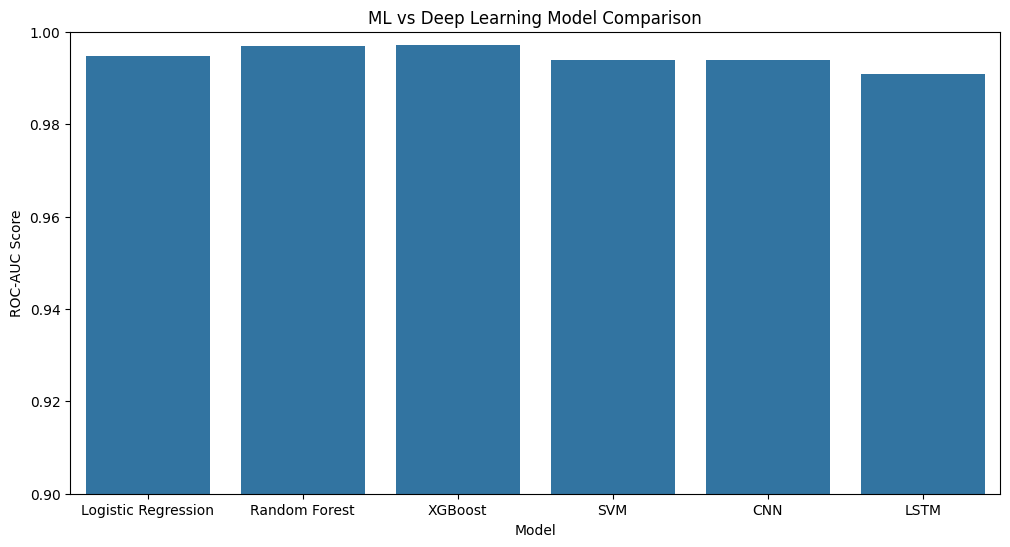

In [13]:
import seaborn as sns
plt.figure(figsize=(12,6))
sns.barplot(
    x='Model',
    y='ROC-AUC',
    data=final_results
)
plt.title("ML vs Deep Learning Model Comparison")
plt.ylim(0.9, 1.0)
plt.ylabel("ROC-AUC Score")
plt.show()

In [14]:
final_results.to_csv(r"D:\Projects\Exoplanet-Detection\data\processed\final_results.csv", index=False)
print("Final results saved successfully")

Final results saved successfully
